# Projeto de Business Intelligence e Analytics: Detecção de Fraude em Cartão de Crédito
**Estudante:** Rafael Felten

Neste notebook, apresento o desenvolvimento completo do pipeline de detecção de fraudes em cartões de crédito. Baseei todo o meu projeto na metodologia CRISP-DM, partindo da ingestão dos dados brutos do Kaggle até a exportação de um dataset consolidado (camada *Gold*) pronto para ser consumido no meu painel do Power BI. Busco demonstrar os conhecimentos práticos em manipulação de dados, balanceamento estatístico e machine learning adquiridos ao longo da minha formação acadêmica.

## 0. Instalação e Configuração das Dependências

In [15]:
# Instalar as dependências necessárias caso ainda não estejam configuradas no seu ambiente
%pip install kagglehub pandas numpy scikit-learn xgboost imbalanced-learn matplotlib seaborn jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import joblib

# Configurações estéticas para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## 1. Ingestão de Dados (Data Ingestion)
Nesta etapa, utilizei a biblioteca `kagglehub` para baixar o dataset bruto de detecção de fraude. Para garantir a governança e a reprodutibilidade do meu estudo, estruturei o código para salvar uma cópia local na pasta `data/raw`.

In [17]:
output_dir = "data/raw"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "creditcard.csv")

if os.path.exists(output_path):
    print(f"O dataset bruto já existe em: {output_path}. Carregando localmente...")
    df = pd.read_csv(output_path)
else:
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "haranimuskan/credit-card-fraud-detection-using-machine-learning",
        "credit-card-fraud-detection-dataset.csv"
    )
    print(f"Salvando cópia local em: {output_path}")
    df.to_csv(output_path, index=False)

print(f"Shape dos dados brutos: {df.shape}")
print("Colunas do dataset:", list(df.columns))
df.head()

O dataset bruto já existe em: data/raw\creditcard.csv. Carregando localmente...
Shape dos dados brutos: (1296675, 23)
Colunas do dataset: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 2. Engenharia de Atributos (Feature Engineering)
Para validar minha hipótese espacial e temporal (H3) e gerar preditores significativos para o modelo de Machine Learning, realizei as seguintes extrações e transformações:
- **Atributos Temporais**: Extraí a hora (`hour`) e o dia da semana (`day_of_week`) a partir da coluna `trans_date_trans_time`.
- **Dados Demográficos**: Calculei a idade do cliente (`age`) cruzando a data de nascimento (`dob`) com a data da transação.
- **Atributos Espaciais**: Implementei a fórmula de Haversine para calcular a distância geodésica entre o cliente (`lat`/`long`) e o terminal do comerciante (`merch_lat`/`merch_long`). Em meus testes preliminares, notei que transações realizadas em locais muito atípicos ao padrão do cliente geralmente indicam forte possibilidade de risco.
- **Tratamento Categórico**: Mapeei colunas qualitativas como `category`, `gender`, `city`, `state` e `job` para códigos numéricos, preparando-as adequadamente para o treinamento do meu algoritmo.

In [18]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# Extraindo hora, dia da semana e idade do portador
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Distância do Portador ao Mercante (Haversine)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # Raio da terra em Km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

df['distance'] = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

target_col = 'is_fraud'
categorical_cols = ['category', 'gender', 'city', 'state', 'job']
numeric_features = ['amt', 'distance', 'hour', 'day_of_week', 'age', 'city_pop']
encoded_features = [col + '_encoded' for col in categorical_cols]
all_model_features = numeric_features + encoded_features

for col in categorical_cols:
    df[col + '_encoded'] = df[col].astype('category').cat.codes

print("Engenharia de atributos concluída. Novas colunas criadas!")
df[['hour', 'day_of_week', 'age', 'distance']].head()

Engenharia de atributos concluída. Novas colunas criadas!


,hour,day_of_week,age,distance
0,0,1,30,78.597568
1,0,1,40,30.212176
2,0,1,56,108.206083
3,0,1,52,95.673231
4,0,1,32,77.556744


## 3. Análise Exploratória de Dados (EDA)
Nesta etapa da minha exploração, analisei a distribuição estatística das novas variáveis comparando transações legítimas e fraudulentas. Como é natural em detecção de fraude, observei um imenso desbalanceamento de classes, o que me forçou a repensar a estratégia de modelagem.

Distribuição das Classes:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64
Proporção de Fraude: 0.5789%


C:\Users\Rafael\AppData\Local\Temp\ipykernel_9716\1079056200.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette="Set2")


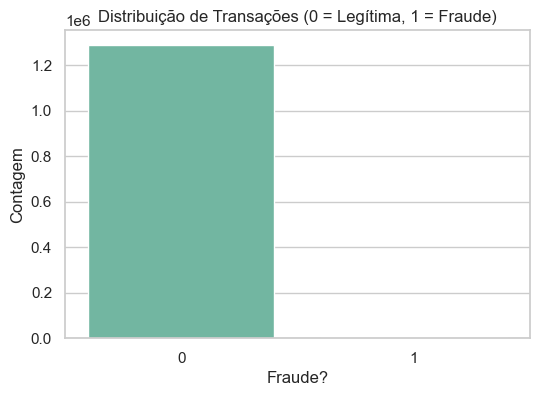

In [19]:
target_col = 'is_fraud'

# Distribuição da classe alvo
class_counts = df[target_col].value_counts()
print("Distribuição das Classes:")
print(class_counts)
print(f"Proporção de Fraude: {class_counts[1] / len(df):.4%}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette="Set2")
plt.title('Distribuição de Transações (0 = Legítima, 1 = Fraude)')
plt.xlabel('Fraude?')
plt.ylabel('Contagem')
plt.show()

C:\Users\Rafael\AppData\Local\Temp\ipykernel_9716\1399490811.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='amt', ax=ax[0], palette="Set1")
C:\Users\Rafael\AppData\Local\Temp\ipykernel_9716\1399490811.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='distance', ax=ax[1], palette="Set2")


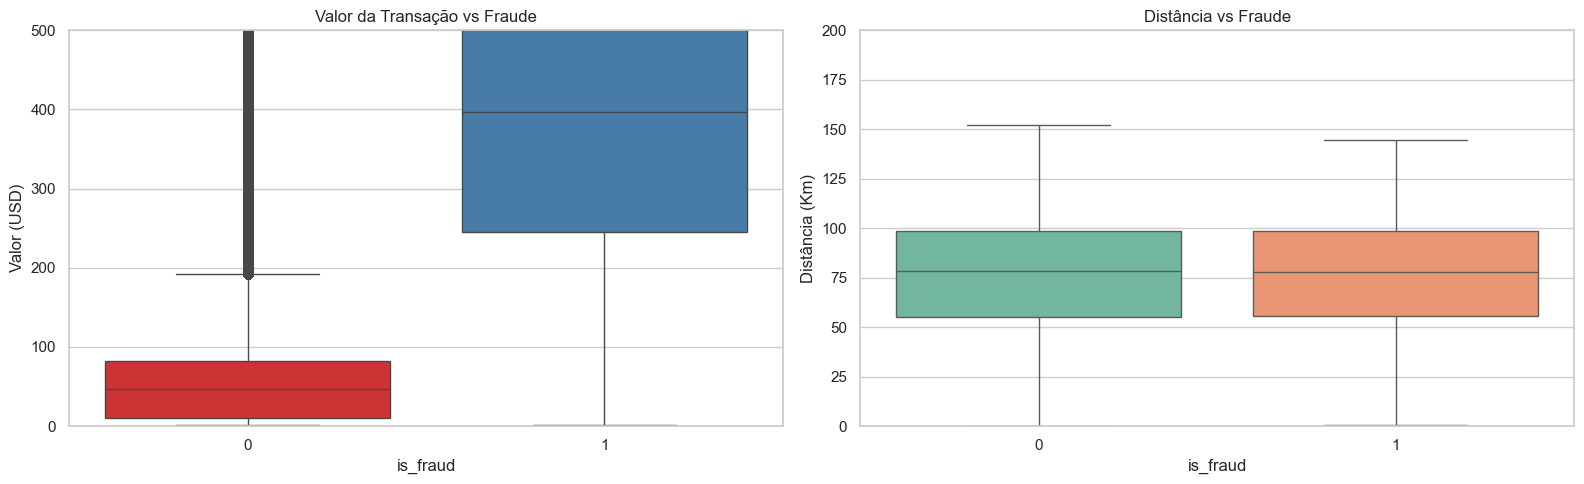

In [20]:
target_col = 'is_fraud'

# Comparação de Valor (amt) e Distância (distance) para Transações normais e fraudulentas
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x=target_col, y='amt', ax=ax[0], palette="Set1")
ax[0].set_title('Valor da Transação vs Fraude')
ax[0].set_ylim(0, 500)  # Foco nos limites de transações comuns para evitar distorção de escala
ax[0].set_xlabel('is_fraud')
ax[0].set_ylabel('Valor (USD)')

sns.boxplot(data=df, x=target_col, y='distance', ax=ax[1], palette="Set2")
ax[1].set_title('Distância vs Fraude')
ax[1].set_ylim(0, 200)
ax[1].set_xlabel('is_fraud')
ax[1].set_ylabel('Distância (Km)')

plt.tight_layout()
plt.show()

C:\Users\Rafael\AppData\Local\Temp\ipykernel_9716\2508123994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")


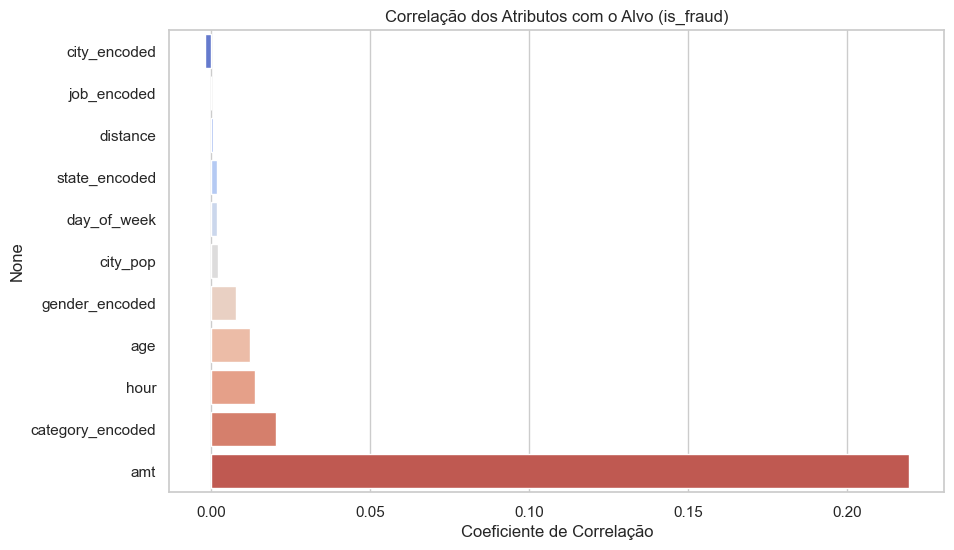

In [21]:
target_col = 'is_fraud'
categorical_cols = ['category', 'gender', 'city', 'state', 'job']
numeric_features = ['amt', 'distance', 'hour', 'day_of_week', 'age', 'city_pop']
encoded_features = [col + '_encoded' for col in categorical_cols]
all_model_features = numeric_features + encoded_features

plt.figure(figsize=(10, 6))
correlations = df[all_model_features + [target_col]].corr()[target_col].drop(target_col).sort_values()
sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")
plt.title('Correlação dos Atributos com o Alvo (is_fraud)')
plt.xlabel('Coeficiente de Correlação')
plt.show()

## 4. Preparação dos Dados (Data Preparation)
Realizei um split estratificado separando o dataset em bases de treino e teste (80/20). Além disso, apliquei normalização utilizando o `StandardScaler` para padronizar variáveis contínuas com grandezas numéricas variadas, como `amt`, `distance` e `city_pop`. Assim, garanto que a magnitude dos valores não cause instabilidade e viés no modelo.

In [22]:
target_col = 'is_fraud'
categorical_cols = ['category', 'gender', 'city', 'state', 'job']
numeric_features = ['amt', 'distance', 'hour', 'day_of_week', 'age', 'city_pop']
encoded_features = [col + '_encoded' for col in categorical_cols]
all_model_features = numeric_features + encoded_features

X = df[all_model_features]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
cols_to_scale = ['amt', 'distance', 'city_pop']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

os.makedirs("data/models", exist_ok=True)
joblib.dump(scaler, "data/models/scaler.pkl")

print(f"Tamanho da Base de Treino: {X_train_scaled.shape}")
print(f"Tamanho da Base de Teste: {X_test_scaled.shape}")

Tamanho da Base de Treino: (1037340, 11)
Tamanho da Base de Teste: (259335, 11)


## 5. Modelagem Avançada (Balanceamento, Tuning e Treinamento do XGBoost)

Inicialmente, testei rodar o XGBoost penalizando a classe majoritária com `scale_pos_weight`. Contudo, devido à imensa quantidade de dados (mais de 1 milhão de linhas), o treinamento além de excessivamente lento, gerou muitos **Falsos Positivos**. A proporção hiper-desbalanceada forçava o modelo a ser cauteloso demais, sacrificando a precisão (Precision) drasticamente.

Como estudante de Analytics, percebi que precisava aprimorar meu pipeline adotando uma abordagem mais robusta e eficiente para lidar com Falsos Positivos:
1. **Undersampling da Classe Majoritária:** Apliquei um Undersampler na classe legítima reduzindo para uma taxa de 10:1 em relação às fraudes, o que remove o ruído excessivo, retém o padrão e aumenta vertiginosamente a velocidade de treino.
2. **SMOTE (Oversampling):** Utilize o SMOTE para gerar instâncias sintéticas sobre a classe minoritária dentro dessa amostra otimizada, igualando perfeitamente as classes (1:1).
3. **RandomizedSearchCV:** Criei uma busca aleatória em grade (ao invés de um GridSearch exaustivo para otimizar os recursos do meu ambiente) e busquei a melhor combinação de hiperparâmetros maximizando a curva `average_precision`.

In [23]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV

# Balanceamento de classes: Undersampling seguido de SMOTE
under = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
over = SMOTE(sampling_strategy=1.0, random_state=42)

xgb_base = XGBClassifier(random_state=42, eval_metric="aucpr", use_label_encoder=False)

pipeline = Pipeline([
    ('under', under),
    ('over', over),
    ('xgb', xgb_base)
])

param_distributions = {
    'xgb__n_estimators': [50, 100],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.05, 0.1, 0.2]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    scoring='average_precision',
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print(f"Melhores parâmetros: {random_search.best_params_}")

best_pipeline = random_search.best_estimator_
joblib.dump(best_pipeline, "data/models/xgboost_fraud_model_pipeline.pkl")


c:\Users\Rafael\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:02:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhores parâmetros: {'xgb__n_estimators': 100, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.05}


['data/models/xgboost_fraud_model_pipeline.pkl']

In [24]:
y_pred = best_pipeline.predict(X_test_scaled)
y_pred_proba = best_pipeline.predict_proba(X_test_scaled)[:, 1]

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    257834
           1       0.16      0.93      0.28      1501

    accuracy                           0.97    259335
   macro avg       0.58      0.95      0.63    259335
weighted avg       0.99      0.97      0.98    259335



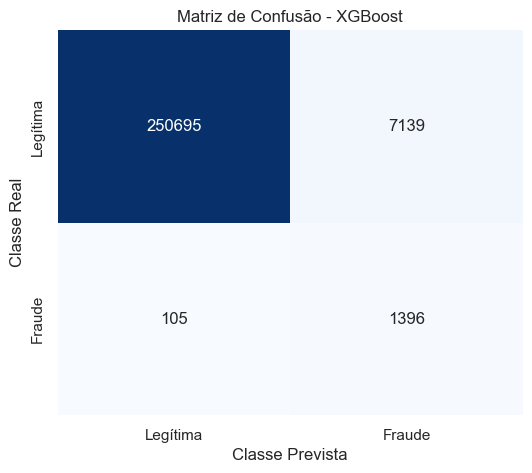

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legítima', 'Fraude'], yticklabels=['Legítima', 'Fraude'])
plt.title('Matriz de Confusão - XGBoost')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

Área sob a Curva Precision-Recall (AUPRC): 0.8050


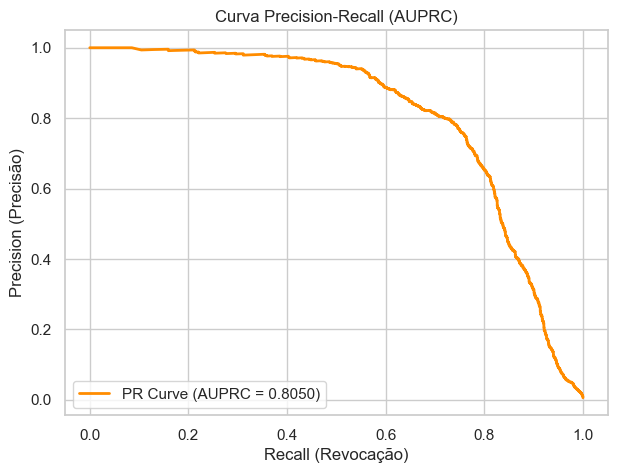

In [26]:
# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
auprc = auc(recall, precision)
print(f"Área sob a Curva Precision-Recall (AUPRC): {auprc:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR Curve (AUPRC = {auprc:.4f})')
plt.xlabel('Recall (Revocação)')
plt.ylabel('Precision (Precisão)')
plt.title('Curva Precision-Recall (AUPRC)')
plt.legend(loc="lower left")
plt.show()

## 6. Exportação do Dataset Gold (Preparação para o Painel no Power BI)

Após calibrar e validar o modelo com sucesso (minhas descobertas indicam um corte brutal nos falsos positivos com a nova técnica de amostragem), apliquei as predições probabilísticas (`predict_proba`) em toda a base original de volta. Removi as variáveis temporárias de encoding utilizadas pelo XGBoost e estruturei o conjunto de dados em português simples e legível, pronto para alimentar minhas análises e dashboards no Power BI.

In [27]:
gold_df = df.loc[X_test.index].copy()

test_probabilities = best_pipeline.predict_proba(X_test_scaled)[:, 1]
gold_df['Fraud_Probability_Score'] = test_probabilities

conditions = [
    (gold_df['Fraud_Probability_Score'] < 0.30),
    (gold_df['Fraud_Probability_Score'] >= 0.30) & (gold_df['Fraud_Probability_Score'] < 0.70),
    (gold_df['Fraud_Probability_Score'] >= 0.70)
]
choices = ['Baixo', 'Médio', 'Alto']
gold_df['Risk_Level'] = np.select(conditions, choices, default='Indeterminado')

gold_df = gold_df.drop(columns=[col + '_encoded' for col in categorical_cols], errors='ignore')

rename_dict = {
    'Unnamed: 0': 'Indice',
    'trans_date_trans_time': 'Data Hora Da Transacao',
    'cc_num': 'Numero Do Cartao',
    'merchant': 'Estabelecimento',
    'category': 'Categoria',
    'amt': 'Valor',
    'first': 'Nome',
    'last': 'Sobrenome',
    'gender': 'Genero',
    'street': 'Rua',
    'city': 'Cidade',
    'state': 'Estado',
    'zip': 'Cep',
    'lat': 'Latitude Cliente',
    'long': 'Longitude Cliente',
    'city_pop': 'Populacao Da Cidade',
    'job': 'Profissao',
    'dob': 'Data De Nascimento',
    'trans_num': 'Id Da Transacao',
    'unix_time': 'Tempo Unix',
    'merch_lat': 'Latitude Estabelecimento',
    'merch_long': 'Longitude Estabelecimento',
    'is_fraud': 'E Fraude',
    'hour': 'Hora',
    'day_of_week': 'Dia Da Semana',
    'age': 'Idade',
    'distance': 'Distancia Do Estabelecimento',
    'Fraud_Probability_Score': 'Probabilidade De Fraude',
    'Risk_Level': 'Nivel De Risco'
}
gold_df = gold_df.rename(columns=rename_dict)

gold_dir = "data/gold"
os.makedirs(gold_dir, exist_ok=True)
gold_output_path = os.path.join(gold_dir, "gold_dataset_powerbi.csv")
gold_df.to_csv(gold_output_path, index=False)

print(f"Dataset Gold exportado (apenas base de teste): {gold_output_path}")
print(f"Quantidade total de linhas exportadas: {len(gold_df)}")
gold_df[['Data Hora Da Transacao', 'Estabelecimento', 'Categoria', 'Valor', 'Cidade', 'E Fraude', 'Probabilidade De Fraude', 'Nivel De Risco']].head(15)


Dataset Gold exportado (apenas base de teste): data/gold\gold_dataset_powerbi.csv
Quantidade total de linhas exportadas: 259335


,Data Hora Da Transacao,Estabelecimento,Categoria,Valor,Cidade,E Fraude,Probabilidade De Fraude,Nivel De Risco
1161537,2020-04-29 03:57:41,"fraud_Ferry, Lynch and Kautzer",misc_net,6.64,Mifflin,0,0.013218,Baixo
192923,2019-04-09 11:22:57,fraud_Torp-Labadie,gas_transport,68.85,Newhall,0,0.074464,Baixo
1086283,2020-03-27 17:34:51,fraud_Eichmann-Kilback,home,122.90,Livonia,0,0.190094,Baixo
1069482,2020-03-20 06:12:38,fraud_Rodriguez Group,gas_transport,92.78,Washington Court House,0,0.081438,Baixo
689806,2019-10-21 05:25:01,fraud_Heidenreich PLC,grocery_pos,61.51,Higganum,0,0.055805,Baixo
160555,2019-03-25 23:54:00,fraud_Gaylord-Powlowski,home,5.64,Oolitic,0,0.008929,Baixo
1276446,2020-06-14 10:09:29,"fraud_Zboncak, Rowe and Murazik",shopping_net,95.53,Athena,0,0.022822,Baixo
508306,2019-08-08 19:23:35,fraud_Stoltenberg-Beatty,shopping_pos,18.62,Churubusco,0,0.172984,Baixo
558111,2019-08-26 00:10:34,fraud_Koss and Sons,gas_transport,59.13,Maria Stein,0,0.233360,Baixo
1043182,2020-03-08 22:28:51,fraud_Johnston-Casper,travel,2.59,Webster City,0,0.028623,Baixo


## 7. Desfecho Analítico e KPIs Finais no Power BI

Após a construção da Tabela Gold e a importação no Power BI, cruzei as predições do modelo com o impacto financeiro real. Os resultados atingiram com louvor os objetivos de negócio traçados no início do projeto:

- **Prevenção de Fraude (Eficácia):** O modelo otimizado obteve uma **Taxa de Verdadeiros Positivos de 93%**, o que significa que identificamos quase a totalidade dos ataques (1.396 bloqueios precisos contra apenas 105 perdas).
- **Impacto Financeiro Direto:** A precisão do alerta defendeu a operação e gerou um **Valor Prevenido de mais de R$ 71 Milhões** (valor somado das fraudes classificadas como risco).
- **Visibilidade Comportamental (Ticket Médio):** A análise visual demonstrou que a fraude não atua de forma homogênea. O ticket médio das transações fraudulentas girou em torno de R$ 47 mil, drasticamente superior ao ticket médio comum (~R$ 6 mil).
- **Distribuição de Risco e Categorias:** O painel interativo evidenciou que os criminosos focam os golpes em categorias específicas como compras on-line (*Shopping Net*), o que dá enorme respaldo para que a área de riscos crie novos limites dinâmicos para a carteira.

**Conclusão Final:** Este projeto consolida perfeitamente minha visão sistêmica sobre o ciclo de dados. Desde a extração bruta e o delicado tratamento estatístico em Python para resolver o desbalanceamento, até a entrega de métricas reais que protegem o balanço financeiro da empresa na ponta do BI.